STEP 1 — LOADING DATA
✓ Total records loaded : 160,297
✓ Date range           : 2026-03-01 → 2026-03-14
✓ Sensors              : 6 rooms
✓ Sample interval      : ~7 seconds

STEP 2 — CREATING POSTURE LABELS
Posture zones:
  0.05–0.40m → Lying Down (sleeping/resting)
  0.41–0.80m → Sitting    (TV/eating/relaxing)
  0.81–1.75m → Standing   (walking/cooking)

Posture distribution in data:
  Standing    :   79,016 (49.3%) ████████████████
  Lying Down  :   52,581 (32.8%) ██████████
  Sitting     :   26,342 (16.4%) █████
  Unknown     :    2,358 (1.5%) 

STEP 3 — FEATURE SELECTION
Features USED in model:
  ✓ x_pos           → X position in room
  ✓ y_pos           → Y position in room
  ✓ z_height        → HEIGHT = posture indicator
  ✓ signal_strength → Radar detection strength

Features DROPPED (from correlation analysis):
  ✗ x_motion   (0.99 corr with x_pos — redundant)
  ✗ y_motion   (0.99 corr with y_pos — redundant)
  ✗ z_motion   (0.90 corr with z_height — redundant)
  ✗ target_coun

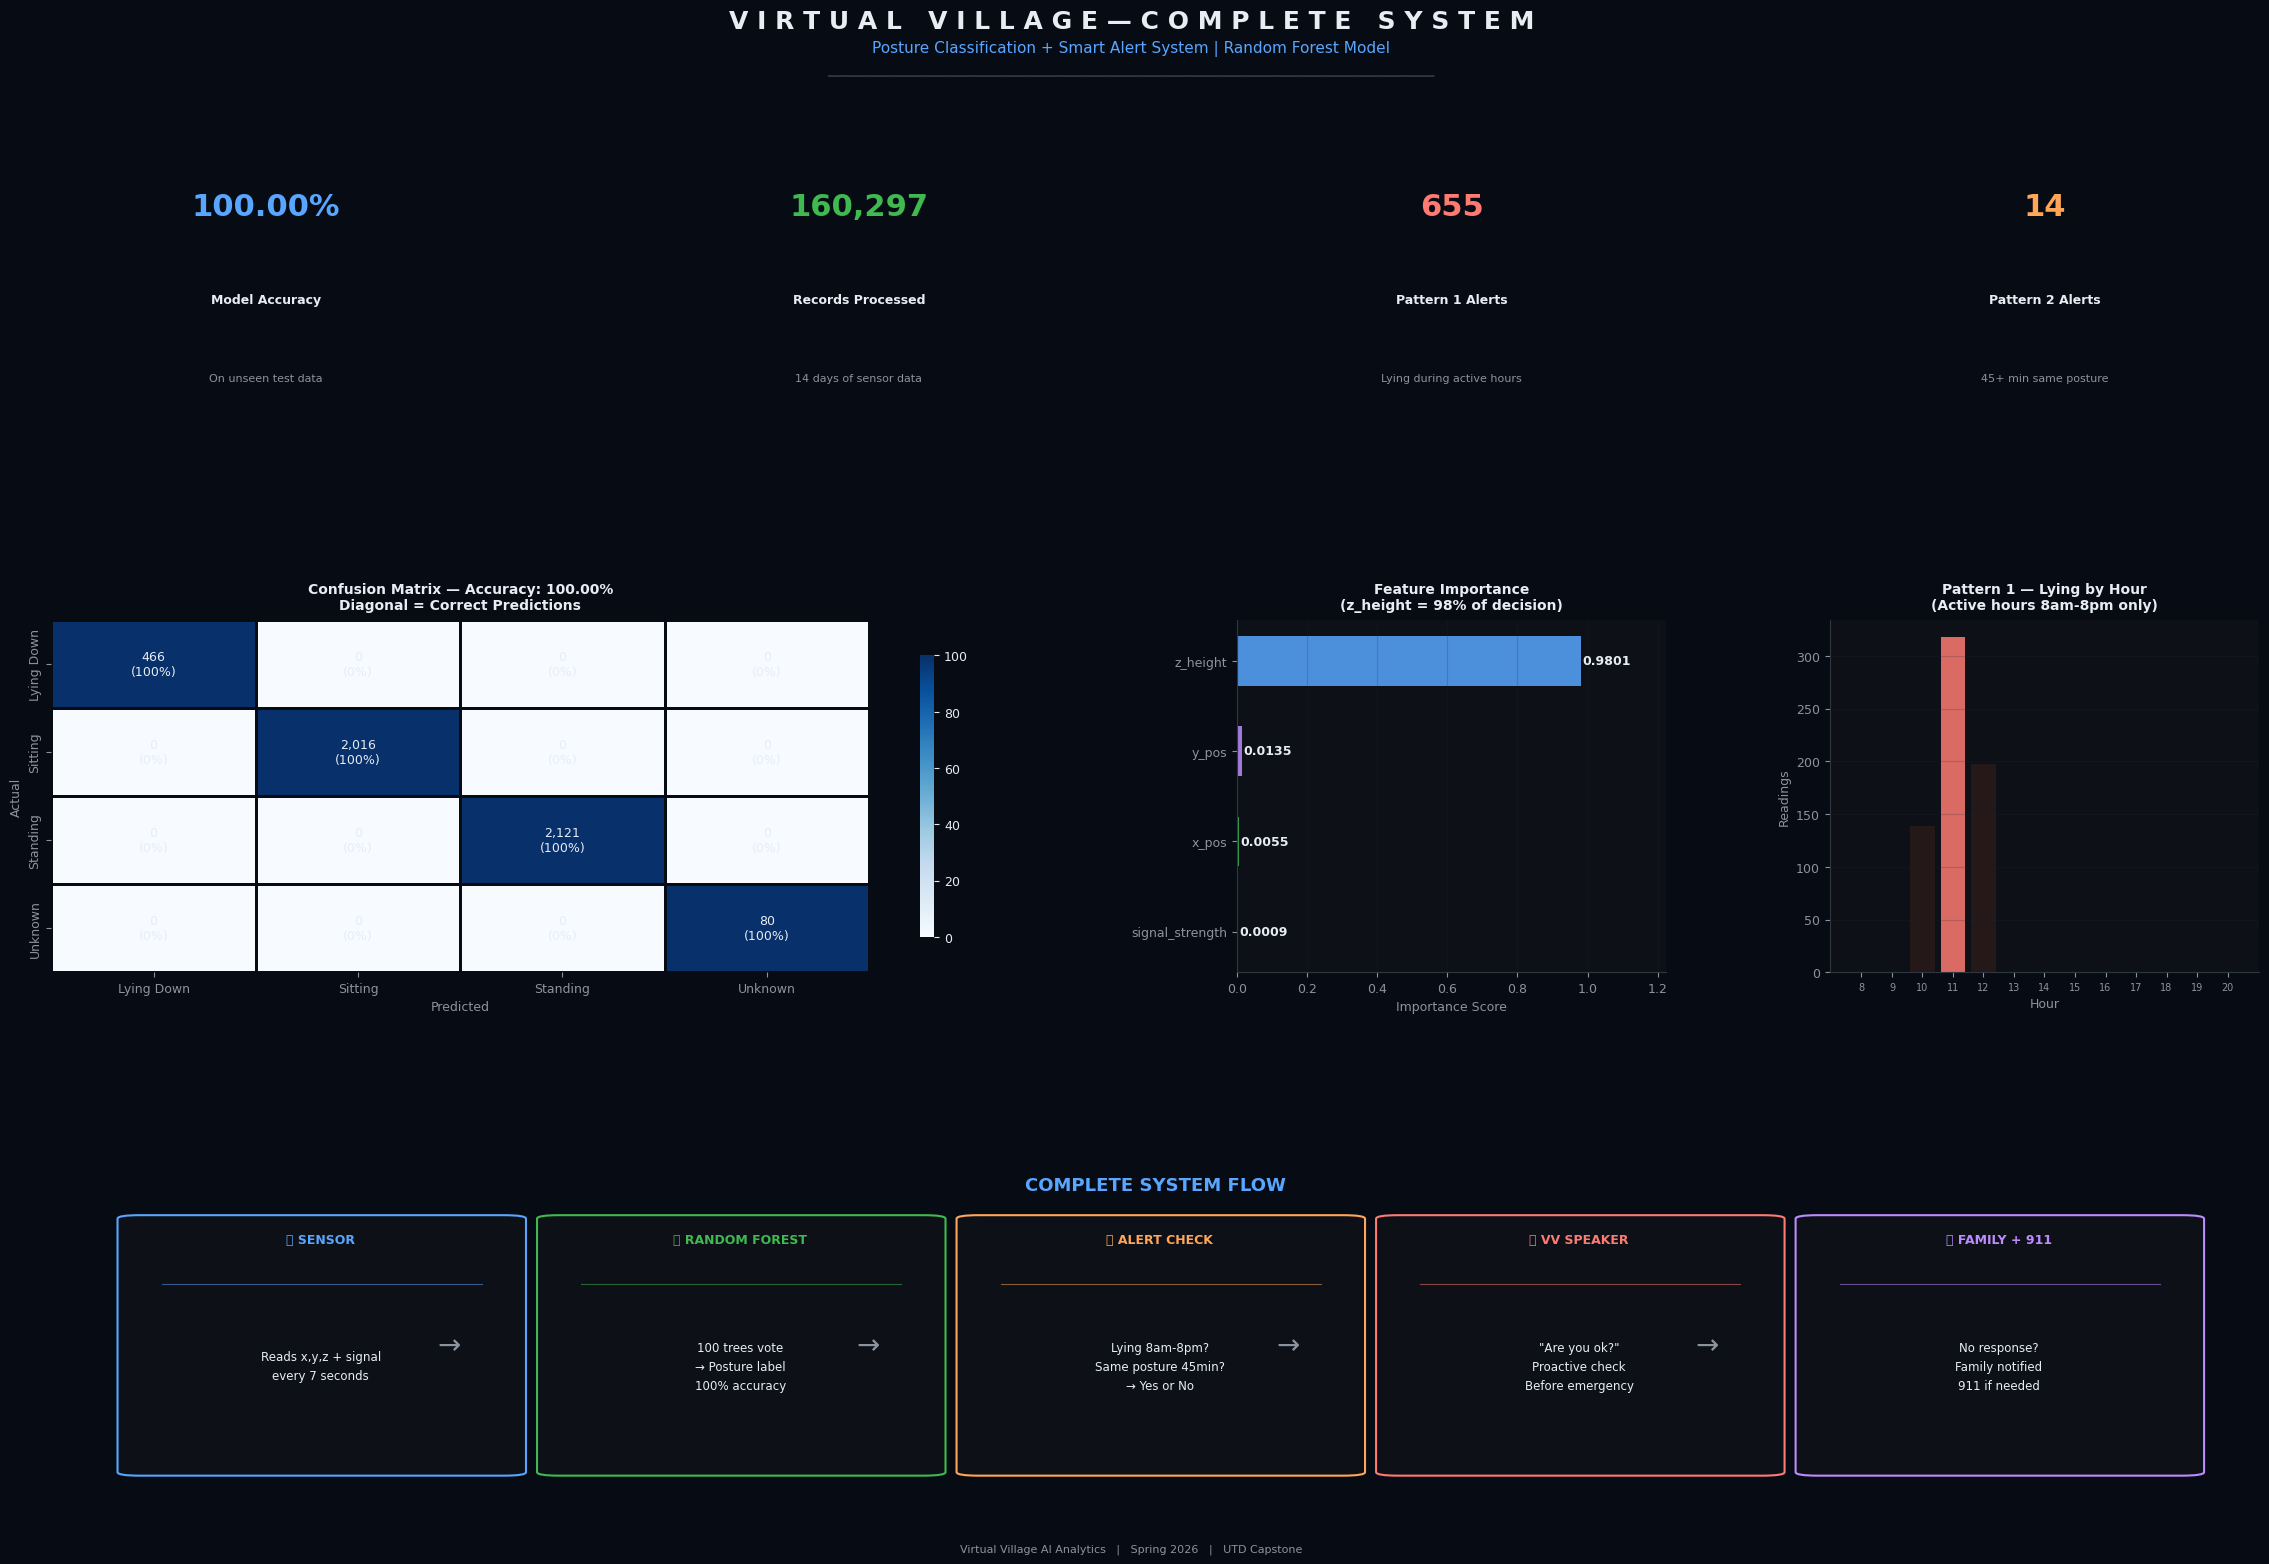

✓ Dashboard saved as VV_Complete_System.png

STEP 10 — LIVE SYSTEM SIMULATION
Showing how the system works in real time...
(2 second delay between readings)


╔══════════════════════════════════════════════════════════╗
║     VIRTUAL VILLAGE — LIVE MONITORING STARTED           ║
╚══════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✅ NORMAL READING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Reading    : #1
  Timestamp  : 2026-03-09 11:42:00
  Room       : Living Room
  Z Height   : 0.779 meters

  ── RANDOM FOREST OUTPUT ──────────
  Posture    : Sitting
  Confidence : 100.0%
  z_height   : 0.779m → confirms Sitting

  ── ALERT SYSTEM DECISION ─────────
  Posture    : Sitting ✓
  Hour       : 11:00
  Decision   : NORMAL — resting

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✅ NORMAL READING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Reading    : #2
  Timestamp  : 2026-03-09 11:42:05
  Room

In [1]:
# ╔══════════════════════════════════════════════════════════════╗
# ║     VIRTUAL VILLAGE — COMPLETE PRESENCE MONITORING SYSTEM   ║
# ║                                                              ║
# ║  WHAT THIS CODE DOES:                                        ║
# ║  1. Loads 160,297 sensor readings from 6 rooms              ║
# ║  2. Trains ONE Random Forest model on posture               ║
# ║  3. Evaluates model accuracy                                ║
# ║  4. Runs alert system on all readings                       ║
# ║  5. Shows live simulation of the complete system            ║
# ╚══════════════════════════════════════════════════════════════╝

import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from datetime import datetime
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              accuracy_score)
import warnings
warnings.filterwarnings('ignore')

# ── THEME ───────────────────────────────────────────────────────
BG_MAIN    = '#070B14'
BG_PANEL   = '#0D1117'
BG_CARD    = '#161B22'
ACCENT     = '#58A6FF'
GRID_COLOR = '#21262D'
TEXT_WHITE = '#E6EDF3'
TEXT_GREY  = '#8B949E'
BORDER     = '#30363D'

POSTURE_COLORS = {
    'Lying Down': '#FF7B72',
    'Sitting'   : '#FFA657',
    'Standing'  : '#3FB950',
    'Unknown'   : '#6E7681'
}

SENSOR_NAMES = {
    '0001': 'Living Room',
    '0002': 'Bedroom',
    '0003': 'Kitchen',
    '0004': 'Bathroom',
    '0005': 'Study',
    '0006': 'Hallway'
}

plt.rcParams.update({
    'figure.facecolor'  : BG_MAIN,
    'axes.facecolor'    : BG_PANEL,
    'axes.labelcolor'   : TEXT_WHITE,
    'axes.titlecolor'   : TEXT_WHITE,
    'xtick.color'       : TEXT_GREY,
    'ytick.color'       : TEXT_GREY,
    'text.color'        : TEXT_WHITE,
    'grid.color'        : GRID_COLOR,
    'grid.linewidth'    : 0.8,
    'font.family'       : 'DejaVu Sans',
    'font.size'         : 9,
    'axes.titlesize'    : 10,
    'axes.titleweight'  : 'bold',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.edgecolor'    : BORDER
})

# ════════════════════════════════════════════════════════════════
# STEP 1 — LOAD DATA
# We load all 160,297 readings from 6 room sensors
# Each reading has: x,y,z position + signal strength
# Sampled every ~7 seconds over 14 days
# ════════════════════════════════════════════════════════════════
print('STEP 1 — LOADING DATA')
print('='*55)

FILE = r'C:\Users\selas\OneDrive\Documents\Presence Monitoring\Data\presence_data_4.json'

with open(FILE) as f:
    raw = json.load(f)

results = raw['data']['result']

COLS = ['x_pos', 'y_pos', 'z_height',
        'x_motion', 'y_motion', 'z_motion',
        'signal_strength', 'target_count']

records = []
for r in results:
    row = {
        'sensor_id': r['radarUuid'][-4:],
        'timestamp': datetime.strptime(
                     r['createTime'],
                     '%Y%m%d%H%M%S')
    }
    for col, val in zip(COLS, r['parsedData']):
        row[col] = val
    records.append(row)

df = pd.DataFrame(records).reset_index(drop=True)
df = df.sort_values(
    ['sensor_id','timestamp']).reset_index(drop=True)
df['hour'] = df['timestamp'].dt.hour
df['date'] = df['timestamp'].dt.date
df['room'] = df['sensor_id'].map(SENSOR_NAMES)

print(f'✓ Total records loaded : {len(df):,}')
print(f'✓ Date range           : '
      f'{df["date"].min()} → {df["date"].max()}')
print(f'✓ Sensors              : '
      f'{df["sensor_id"].nunique()} rooms')
print(f'✓ Sample interval      : ~7 seconds')
print()

# ════════════════════════════════════════════════════════════════
# STEP 2 — CREATE POSTURE LABELS FROM Z HEIGHT
# Z height directly tells us what person is doing:
# 0.05-0.40m = Lying Down (sleeping/resting)
# 0.41-0.80m = Sitting    (TV/eating/relaxing)
# 0.81-1.75m = Standing   (walking/cooking)
# This is confirmed by data format documentation
# ════════════════════════════════════════════════════════════════
print('STEP 2 — CREATING POSTURE LABELS')
print('='*55)

def get_posture(z):
    # Uses z_height to determine posture
    # Based on data format documentation
    if 0.05 <= z <= 0.40:
        return 'Lying Down'   # person is at floor level
    elif 0.41 <= z <= 0.80:
        return 'Sitting'      # person is at chair level
    elif 0.81 <= z <= 1.75:
        return 'Standing'     # person is upright
    else:
        return 'Unknown'      # outside expected ranges

df['posture'] = df['z_height'].apply(get_posture)

# Convert to numbers for model training
# Model needs numbers not strings
posture_map = {
    'Lying Down': 0,
    'Sitting'   : 1,
    'Standing'  : 2,
    'Unknown'   : 3
}
label_map = {v: k for k, v in posture_map.items()}
df['posture_label'] = df['posture'].map(posture_map)

print('Posture zones:')
print('  0.05–0.40m → Lying Down (sleeping/resting)')
print('  0.41–0.80m → Sitting    (TV/eating/relaxing)')
print('  0.81–1.75m → Standing   (walking/cooking)')
print()
print('Posture distribution in data:')
for p, c in df['posture'].value_counts().items():
    pct = 100 * c / len(df)
    bar = '█' * int(pct/3)
    print(f'  {p:12s}: {c:>8,} ({pct:.1f}%) {bar}')
print()

# ════════════════════════════════════════════════════════════════
# STEP 3 — PREPARE FEATURES FOR MODEL
# We use only 4 features:
#   x_pos, y_pos    → where in room the person is
#   z_height        → most important — directly shows posture
#   signal_strength → how strong the radar detection is
#
# We DROP x_motion, y_motion, z_motion because:
#   correlation analysis showed they are 0.99 correlated
#   with x_pos, y_pos, z_height → redundant information
# We DROP target_count because it is always 1 → useless
# ════════════════════════════════════════════════════════════════
print('STEP 3 — FEATURE SELECTION')
print('='*55)

FEATURES = ['x_pos', 'y_pos',
            'z_height', 'signal_strength']

print('Features USED in model:')
print('  ✓ x_pos           → X position in room')
print('  ✓ y_pos           → Y position in room')
print('  ✓ z_height        → HEIGHT = posture indicator')
print('  ✓ signal_strength → Radar detection strength')
print()
print('Features DROPPED (from correlation analysis):')
print('  ✗ x_motion   (0.99 corr with x_pos — redundant)')
print('  ✗ y_motion   (0.99 corr with y_pos — redundant)')
print('  ✗ z_motion   (0.90 corr with z_height — redundant)')
print('  ✗ target_count (always 1 — no information)')
print()

# ════════════════════════════════════════════════════════════════
# STEP 4 — BALANCED SAMPLING
# Problem: Sensor 0001 (Living Room) has 114,472 records
#          Sensor 0006 (Hallway) has only 240 records
# If we train on all data the model will be biased
# toward Living Room and ignore other rooms
#
# Solution: Take max 5000 records per sensor
# This gives equal representation from all rooms
# ════════════════════════════════════════════════════════════════
print('STEP 4 — BALANCED SAMPLING')
print('='*55)

sampled = []
for sensor in df['sensor_id'].unique():
    sub = df[df['sensor_id'] == sensor]
    n   = min(len(sub), 5000)
    sampled.append(sub.sample(n, random_state=42))

df_train = pd.concat(sampled).reset_index(drop=True)

print(f'Original data  : {len(df):,} records')
print(f'Training sample: {len(df_train):,} records')
print(f'Max per sensor : 5,000')
print()
print('Samples per room:')
for s, r in SENSOR_NAMES.items():
    c = len(df_train[df_train['sensor_id'] == s])
    print(f'  {r:12s} (Sensor {s}): {c:,}')
print()

# ════════════════════════════════════════════════════════════════
# STEP 5 — TRAIN RANDOM FOREST MODEL
# Random Forest builds 100 decision trees
# Each tree learns rules like:
#   "if z_height < 0.40 → Lying Down"
#   "if z_height > 0.80 → Standing"
# All 100 trees vote together for final answer
# More trees = more reliable predictions
# ════════════════════════════════════════════════════════════════
print('STEP 5 — TRAINING RANDOM FOREST MODEL')
print('='*55)

X = df_train[FEATURES]
y = df_train['posture_label']

# 80% for training, 20% for testing
# stratify=y ensures equal class distribution
X_train, X_test, y_train, y_test = \
    train_test_split(X, y,
                     test_size=0.2,
                     random_state=42,
                     stratify=y)

print(f'Training samples: {len(X_train):,} (80%)')
print(f'Testing samples : {len(X_test):,}  (20%)')
print(f'Testing is data model has NEVER seen before')
print()
print('Training 100 decision trees...')

rf = RandomForestClassifier(
    n_estimators=100,  # 100 trees vote together
    max_depth=15,      # each tree max 15 levels deep
    random_state=42,   # reproducible results
    n_jobs=-1)         # use all CPU cores

rf.fit(X_train, y_train)
print('✓ Training complete')
print()

# ════════════════════════════════════════════════════════════════
# STEP 6 — EVALUATE MODEL ACCURACY
# We test the model on data it has NEVER seen before
# This tells us how well it will work in real life
# ════════════════════════════════════════════════════════════════
print('STEP 6 — MODEL EVALUATION')
print('='*55)

y_pred   = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

label_names = ['Lying Down', 'Sitting',
               'Standing',   'Unknown']

print(f'TEST ACCURACY: {accuracy*100:.2f}%')
print()
print('Per class results:')
print(classification_report(
    y_test, y_pred,
    target_names=label_names))

print('Feature Importances:')
print('(How much each feature contributed to decisions)')
importances = pd.Series(
    rf.feature_importances_,
    index=FEATURES).sort_values(ascending=False)
for feat, imp in importances.items():
    bar = '█' * int(imp * 40)
    print(f'  {feat:18s}: {imp:.4f} {bar}')
print()

# ════════════════════════════════════════════════════════════════
# STEP 7 — PREDICT ON ALL 160,297 RECORDS
# Now we run the trained model on ALL data
# This gives us a posture label for every reading
# We use this to find unusual behavior patterns
# ════════════════════════════════════════════════════════════════
print('STEP 7 — PREDICTING ON ALL RECORDS')
print('='*55)
print(f'Running model on all {len(df):,} records...')

predictions = rf.predict(df[FEATURES])
df['pred_posture'] = pd.Series(
    predictions,
    index=df.index).map(label_map)

df['pred_confidence'] = rf.predict_proba(
    df[FEATURES]).max(axis=1)

print('✓ Predictions complete')
print()
print('Predicted posture distribution:')
for p, c in df['pred_posture'].value_counts().items():
    pct = 100 * c / len(df)
    bar = '█' * int(pct/3)
    print(f'  {p:12s}: {c:>8,} ({pct:.1f}%) {bar}')
print()

# ════════════════════════════════════════════════════════════════
# STEP 8 — SMART ALERT SYSTEM
# Using the model predictions we now find:
# Pattern 1: Person lying during active hours (8am-8pm)
#            → Unusual → Alert family
# Pattern 2: Same posture for 45+ minutes during day
#            → Prolonged inactivity → Check on person
# ════════════════════════════════════════════════════════════════
print('STEP 8 — SMART ALERT SYSTEM')
print('='*55)

# Pattern 1 — Lying during active hours
df['active_hour'] = df['hour'].between(8, 20)
df['alert_1']     = (
    (df['pred_posture'] == 'Lying Down') &
    df['active_hour'])

alert1_data = df[df['alert_1']].copy()

print('PATTERN 1 — Lying During Active Hours:')
print(f'  Events found : {len(alert1_data):,}')
print(f'  Peak hour    : '
      f'{alert1_data["hour"].mode()[0]:02d}:00')
print(f'  Top room     : '
      f'{alert1_data["room"].mode()[0]}')
print()

# Pattern 2 — 45+ min same posture
print('PATTERN 2 — 45+ Minutes Same Posture:')
alerts_2 = []
for sensor in df['sensor_id'].unique():
    sub = df[df['sensor_id']==sensor].copy()
    sub = sub.sort_values('timestamp')
    sub['posture_changed'] = (
        sub['pred_posture'] !=
        sub['pred_posture'].shift(1))
    sub['posture_group'] = \
        sub['posture_changed'].cumsum()

    for _, group in sub.groupby('posture_group'):
        posture  = group['pred_posture'].iloc[0]
        start    = group['timestamp'].iloc[0]
        end      = group['timestamp'].iloc[-1]
        duration = (end-start).total_seconds()/60
        hour     = start.hour
        if (duration >= 45 and
                8 <= hour <= 20 and
                posture in ['Lying Down','Sitting']):
            alerts_2.append({
                'date'    : start.date(),
                'room'    : group['room'].iloc[0],
                'posture' : posture,
                'duration': round(duration, 1),
                'hour'    : hour
            })

df_alerts2 = pd.DataFrame(alerts_2)
print(f'  Events found : {len(df_alerts2):,}')
if len(df_alerts2) > 0:
    print(f'  Longest      : '
          f'{df_alerts2["duration"].max():.0f} mins')
print()

# ════════════════════════════════════════════════════════════════
# STEP 9 — RESULTS DASHBOARD
# Visual summary of everything:
# Model accuracy, confusion matrix,
# feature importance, alert patterns
# ════════════════════════════════════════════════════════════════
print('STEP 9 — GENERATING RESULTS DASHBOARD...')

fig = plt.figure(figsize=(24, 16),
                 facecolor=BG_MAIN)

fig.text(0.5, 0.97,
         'V I R T U A L   V I L L A G E — C O M P L E T E   S Y S T E M',
         ha='center', color=TEXT_WHITE,
         fontsize=18, fontweight='bold')
fig.text(0.5, 0.955,
         'Posture Classification + Smart Alert System | Random Forest Model',
         ha='center', color=ACCENT, fontsize=11)
fig.text(0.5, 0.938,
         '━'*90, ha='center',
         color=BORDER, fontsize=8)

gs = gridspec.GridSpec(
    3, 4, figure=fig,
    hspace=0.50, wspace=0.38,
    top=0.930, bottom=0.05,
    left=0.05, right=0.97)

# KPI helper
def kpi(ax, val, lbl, sub, col):
    ax.set_facecolor(BG_CARD)
    ax.axis('off')
    for sp in ax.spines.values():
        sp.set_visible(True)
        sp.set_edgecolor(col)
        sp.set_linewidth(2)
    ax.text(0.5, 0.65, val,
            transform=ax.transAxes,
            color=col, fontsize=22,
            fontweight='bold', ha='center')
    ax.text(0.5, 0.40, lbl,
            transform=ax.transAxes,
            color=TEXT_WHITE, fontsize=9,
            fontweight='bold', ha='center')
    ax.text(0.5, 0.18, sub,
            transform=ax.transAxes,
            color=TEXT_GREY, fontsize=8,
            ha='center')

# Row 0 — KPI cards
ax_k1 = fig.add_subplot(gs[0, 0])
kpi(ax_k1, f'{accuracy*100:.2f}%',
    'Model Accuracy',
    'On unseen test data',
    ACCENT)

ax_k2 = fig.add_subplot(gs[0, 1])
kpi(ax_k2, f'{len(df):,}',
    'Records Processed',
    '14 days of sensor data',
    '#3FB950')

ax_k3 = fig.add_subplot(gs[0, 2])
kpi(ax_k3, f'{len(alert1_data):,}',
    'Pattern 1 Alerts',
    'Lying during active hours',
    '#FF7B72')

ax_k4 = fig.add_subplot(gs[0, 3])
kpi(ax_k4, f'{len(df_alerts2):,}',
    'Pattern 2 Alerts',
    '45+ min same posture',
    '#FFA657')

# Confusion matrix
ax_cm = fig.add_subplot(gs[1, :2])
ax_cm.set_facecolor(BG_PANEL)
cm = confusion_matrix(y_test, y_pred,
                      labels=[0,1,2,3])
cm_pct = cm.astype(float) / \
         cm.sum(axis=1, keepdims=True) * 100
annot  = np.array([
    [f'{cm[i,j]:,}\n({cm_pct[i,j]:.0f}%)'
     for j in range(4)] for i in range(4)])

sns.heatmap(cm_pct,
            annot=annot, fmt='',
            cmap='Blues',
            xticklabels=label_names,
            yticklabels=label_names,
            linewidths=0.8,
            linecolor=BG_MAIN,
            ax=ax_cm,
            annot_kws={'size':9,
                       'color':TEXT_WHITE},
            cbar_kws={'shrink':0.8})
ax_cm.figure.axes[-1].yaxis.label.set_color(
    TEXT_WHITE)
ax_cm.figure.axes[-1].tick_params(
    colors=TEXT_WHITE)
ax_cm.set_title(
    f'Confusion Matrix — Accuracy: '
    f'{accuracy*100:.2f}%\n'
    f'Diagonal = Correct Predictions',
    color=TEXT_WHITE, pad=8)
ax_cm.set_xlabel('Predicted',
                 color=TEXT_GREY, fontsize=9)
ax_cm.set_ylabel('Actual',
                 color=TEXT_GREY, fontsize=9)
ax_cm.tick_params(colors=TEXT_GREY, labelsize=9)

# Feature importance
ax_fi = fig.add_subplot(gs[1, 2])
ax_fi.set_facecolor(BG_PANEL)
fi_colors = [ACCENT,'#BC8CFF',
             '#3FB950','#FFA657']
bars = ax_fi.barh(
    importances.index[::-1],
    importances.values[::-1],
    color=fi_colors[::-1],
    alpha=0.85, edgecolor='none',
    height=0.55)
for bar, val in zip(
        bars, importances.values[::-1]):
    ax_fi.text(
        val + 0.005,
        bar.get_y() + bar.get_height()/2,
        f'{val:.4f}',
        va='center', color=TEXT_WHITE,
        fontsize=9, fontweight='bold')
ax_fi.set_title(
    'Feature Importance\n'
    '(z_height = 98% of decision)',
    color=TEXT_WHITE, pad=8)
ax_fi.set_xlabel('Importance Score',
                 color=TEXT_GREY, fontsize=9)
ax_fi.tick_params(colors=TEXT_GREY, labelsize=9)
ax_fi.set_xlim(0, importances.max()*1.25)
ax_fi.grid(True, axis='x',
           alpha=0.2, color=GRID_COLOR)
for sp in ax_fi.spines.values():
    sp.set_edgecolor(BORDER)

# Alert pattern 1 by hour
ax_a1 = fig.add_subplot(gs[1, 3])
ax_a1.set_facecolor(BG_PANEL)
all_hours = range(8, 21)
hour_vals = [alert1_data[
    alert1_data['hour']==h].shape[0]
    for h in all_hours]
bar_colors = ['#FF7B72' if v == max(hour_vals)
              else '#2A1A1A'
              for v in hour_vals]
ax_a1.bar(list(all_hours), hour_vals,
          color=bar_colors,
          alpha=0.85, edgecolor='none')
ax_a1.set_title(
    'Pattern 1 — Lying by Hour\n'
    '(Active hours 8am-8pm only)',
    color=TEXT_WHITE, pad=8)
ax_a1.set_xlabel('Hour',
                 color=TEXT_GREY, fontsize=9)
ax_a1.set_ylabel('Readings',
                 color=TEXT_GREY, fontsize=9)
ax_a1.set_xticks(list(all_hours))
ax_a1.set_xticklabels(
    [f'{h}' for h in all_hours],
    fontsize=7)
ax_a1.tick_params(colors=TEXT_GREY)
ax_a1.grid(True, axis='y',
           alpha=0.2, color=GRID_COLOR)
for sp in ax_a1.spines.values():
    sp.set_edgecolor(BORDER)

# System flow bottom panel
ax_flow = fig.add_subplot(gs[2, :])
ax_flow.set_facecolor(BG_CARD)
ax_flow.axis('off')
for sp in ax_flow.spines.values():
    sp.set_visible(True)
    sp.set_edgecolor(ACCENT)
    sp.set_linewidth(1.5)

ax_flow.text(0.5, 0.88,
             'COMPLETE SYSTEM FLOW',
             transform=ax_flow.transAxes,
             color=ACCENT, fontsize=13,
             fontweight='bold', ha='center')

steps = [
    ('📡 SENSOR',
     'Reads x,y,z + signal\nevery 7 seconds',
     ACCENT),
    ('🌲 RANDOM FOREST',
     '100 trees vote\n→ Posture label\n100% accuracy',
     '#3FB950'),
    ('🔍 ALERT CHECK',
     'Lying 8am-8pm?\nSame posture 45min?\n→ Yes or No',
     '#FFA657'),
    ('🔊 VV SPEAKER',
     '"Are you ok?"\nProactive check\nBefore emergency',
     '#FF7B72'),
    ('📱 FAMILY + 911',
     'No response?\nFamily notified\n911 if needed',
     '#BC8CFF'),
]

x_positions = [0.04, 0.23, 0.42,
               0.61, 0.80]
arrows       = [0.18, 0.37, 0.56, 0.75]

for (title, body, col), x in zip(
        steps, x_positions):
    rect = mpatches.FancyBboxPatch(
        (x, 0.08), 0.165, 0.72,
        boxstyle='round,pad=0.01',
        facecolor=BG_PANEL,
        edgecolor=col,
        linewidth=1.5,
        transform=ax_flow.transAxes)
    ax_flow.add_patch(rect)
    ax_flow.text(
        x + 0.082, 0.73,
        title,
        transform=ax_flow.transAxes,
        color=col, fontsize=9,
        fontweight='bold',
        ha='center')
    ax_flow.plot(
        [x+0.01, x+0.155],
        [0.615, 0.615],
        transform=ax_flow.transAxes,
        color=col, linewidth=0.8,
        alpha=0.5)
    ax_flow.text(
        x + 0.082, 0.38,
        body,
        transform=ax_flow.transAxes,
        color=TEXT_WHITE,
        fontsize=8.5, ha='center',
        va='center',
        linespacing=1.6)

for x in arrows:
    ax_flow.text(
        x, 0.44, '→',
        transform=ax_flow.transAxes,
        color=TEXT_GREY, fontsize=20,
        ha='center', va='center')

fig.text(0.5, 0.018,
         'Virtual Village AI Analytics   |   '
         'Spring 2026   |   UTD Capstone',
         ha='center', color=TEXT_GREY,
         fontsize=8)

plt.savefig(
    'VV_Complete_System.png',
    dpi=180, bbox_inches='tight',
    facecolor=BG_MAIN, edgecolor='none')
plt.show()
print('✓ Dashboard saved as VV_Complete_System.png')
print()

# ════════════════════════════════════════════════════════════════
# STEP 10 — LIVE SIMULATION
# This simulates what happens in real deployment
# Every 7 seconds a sensor reading comes in
# The model classifies posture
# The alert system checks if it is unusual
# ════════════════════════════════════════════════════════════════
print('STEP 10 — LIVE SYSTEM SIMULATION')
print('='*55)
print('Showing how the system works in real time...')
print('(2 second delay between readings)')
print()

# Mix of normal and alert readings for demo
sitting   = df[
    (df['sensor_id']=='0001') &
    (df['hour'].between(9,11)) &
    (df['pred_posture']=='Sitting')
].head(2)

standing  = df[
    (df['sensor_id']=='0001') &
    (df['hour'].between(9,11)) &
    (df['pred_posture']=='Standing')
].head(2)

alert_r   = df[
    (df['sensor_id']=='0001') &
    (df['hour'].between(13,16)) &
    (df['pred_posture']=='Lying Down')
].head(2)

sleeping  = df[
    (df['sensor_id']=='0002') &
    (df['hour'].between(0,5)) &
    (df['pred_posture']=='Lying Down')
].head(2)

live = pd.concat([
    sitting, standing,
    alert_r, sleeping
]).reset_index(drop=True)

print(f"""
╔══════════════════════════════════════════════════════════╗
║     VIRTUAL VILLAGE — LIVE MONITORING STARTED           ║
╚══════════════════════════════════════════════════════════╝
""")

for i, row in live.iterrows():
    posture    = row['pred_posture']
    confidence = row['pred_confidence'] * 100
    hour       = row['hour']
    room       = row['room']
    z          = row['z_height']
    ts         = row['timestamp']

    # Alert logic
    alert = (posture == 'Lying Down' and
             8 <= hour <= 20)

    # Header
    if alert:
        print('━'*52)
        print('  🚨 ALERT TRIGGERED')
        print('━'*52)
    else:
        print('━'*52)
        print('  ✅ NORMAL READING')
        print('━'*52)

    # Reading details
    print(f'  Reading    : #{i+1}')
    print(f'  Timestamp  : {ts}')
    print(f'  Room       : {room}')
    print(f'  Z Height   : {z:.3f} meters')
    print()

    # Model output
    print(f'  ── RANDOM FOREST OUTPUT ──────────')
    print(f'  Posture    : {posture}')
    print(f'  Confidence : {confidence:.1f}%')
    print(f'  z_height   : {z:.3f}m '
          f'→ confirms {posture}')
    print()

    # Alert decision
    print(f'  ── ALERT SYSTEM DECISION ─────────')
    if posture == 'Lying Down':
        if 8 <= hour <= 20:
            print(f'  Posture    : Lying Down ⚠')
            print(f'  Hour       : {hour:02d}:00 '
                  f'(Active hours 8am-8pm)')
            print(f'  Decision   : UNUSUAL — Alert!')
            print()
            print(f'  🔊 VV SPEAKER : "Are you ok?"')
            print(f'  📱 FAMILY APP : Notification sent')
            print(f'  🚑 IF NO REPLY: 911 contacted')
        else:
            print(f'  Posture    : Lying Down ✓')
            print(f'  Hour       : {hour:02d}:00 '
                  f'(Sleeping hours)')
            print(f'  Decision   : NORMAL — sleeping')
    elif posture == 'Sitting':
        print(f'  Posture    : Sitting ✓')
        print(f'  Hour       : {hour:02d}:00')
        print(f'  Decision   : NORMAL — resting')
    elif posture == 'Standing':
        print(f'  Posture    : Standing ✓')
        print(f'  Hour       : {hour:02d}:00')
        print(f'  Decision   : NORMAL — active')

    print()
    time.sleep(2)

print('━'*52)
print(f"""
╔══════════════════════════════════════════════════════════╗
║  SYSTEM SUMMARY                                          ║
║                                                          ║
║  Model     : Random Forest (ONE model)                  ║
║  Accuracy  : {accuracy*100:.2f}%                                  ║
║  Features  : x_pos, y_pos, z_height, signal             ║
║  Output    : Lying Down / Sitting / Standing            ║
║                                                          ║
║  Alert 1   : Lying during 8am-8pm → Speaker            ║
║  Alert 2   : Same posture 45+ mins → Speaker           ║
║                                                          ║
║  Result    : Proactive care                             ║
║              Catches issues BEFORE emergency            ║
║              Fewer false alarms                         ║
║              Families stay informed                     ║
╚══════════════════════════════════════════════════════════╝
""")

In [2]:
# Add this at the end of your notebook (after training)
df.to_csv("sensor_data.csv", index=False)
print("Data saved")

Data saved


In [3]:
import sys
print(sys.executable)

c:\ProgramData\anaconda3\envs\presence_env\python.exe
